In [ ]:
import torch
from diffusers import StableDiffusionControlNetPipeline, ControlNetModel
from controlnet_aux import CannyDetector
from PIL import Image
import matplotlib.pyplot as plt
import os


# CONFIGS
dtype = torch.float32   # Global dtype for numerical stability on MPS
steps = 15              # Number of inference steps
seeds = [42, 123, 999]  # Seeds

# Prompt setup
prompt = "A banner image of a summer forest, vibrant colors"

# Models (compatible and publicly accessible)
models = {
    "Stable Diffusion v1.5": "runwayml/stable-diffusion-v1-5",
    "Openjourney": "prompthero/openjourney"
}

print(torch.__version__)
print(torch.backends.mps.is_available())
print(torch.backends.mps.is_built())

# Device setup explicitly for Apple Silicon (MPS)
device = "mps" if torch.backends.mps.is_available() else "cpu"
print(f"Using device: {device}")

# ControlNet setup (Canny)
controlnet = ControlNetModel.from_pretrained(
    "lllyasviel/sd-controlnet-canny",
    torch_dtype=dtype,
    use_safetensors=True
).to(device)

# Pipeline kwargs
pipe_kwargs = {
    "torch_dtype": dtype,
    "use_safetensors": True,
    "safety_checker": None          # AVOIDS image generations beeing filtered to NSFW and sensored
}

# Canny edge detector, current segmentation mask attempt
canny = CannyDetector()

# Input/control image preprocessing
control_image = Image.open("nike.png").resize((512, 512))
control_image_canny = canny(control_image)
control_image_canny.save("canny_test.png")


def make_generator(seed):
    return torch.Generator(device=device).manual_seed(seed)

# Image generation
results = {}
for model_name, model_path in models.items():
    print(f"\nGenerating images with model: {model_name}")
    pipe = StableDiffusionControlNetPipeline.from_pretrained(
        model_path,
        controlnet=controlnet,
        **pipe_kwargs
    ).to(device)

    pipe.enable_attention_slicing()

    model_images = []
    for seed in seeds:
        generator = make_generator(seed)

        image = pipe(
            prompt,
            num_inference_steps=steps,
            guidance_scale=7.5,
            image=control_image_canny,
            generator=generator
        ).images[0]

        # Save
        filename = f"{model_name.replace(' ', '_')}_seed_{seed}.png"
        image.save(filename)
        print(f"✅ Saved: {filename}")

        model_images.append(image)

    results[model_name] = model_images


2.6.0.dev20241112
True
True
Using device: mps

Generating images with model: Stable Diffusion v1.5


Loading pipeline components...: 100%|██████████| 6/6 [00:00<00:00,  7.83it/s]
You have disabled the safety checker for <class 'diffusers.pipelines.controlnet.pipeline_controlnet.StableDiffusionControlNetPipeline'> by passing `safety_checker=None`. Ensure that you abide to the conditions of the Stable Diffusion license and do not expose unfiltered results in services or applications open to the public. Both the diffusers team and Hugging Face strongly recommend to keep the safety filter enabled in all public facing circumstances, disabling it only for use-cases that involve analyzing network behavior or auditing its results. For more information, please have a look at https://github.com/huggingface/diffusers/pull/254 .
100%|██████████| 15/15 [27:20<00:00, 109.38s/it] 


✅ Saved: Stable_Diffusion_v1.5_seed_42.png


100%|██████████| 15/15 [11:08<00:00, 44.54s/it]


✅ Saved: Stable_Diffusion_v1.5_seed_123.png


...

✅ Saved: Openjourney_seed_42.png


100%|██████████| 15/15 [09:18<00:00, 37.23s/it]


✅ Saved: Openjourney_seed_123.png


100%|██████████| 15/15 [07:56<00:00, 31.74s/it]


✅ Saved: Openjourney_seed_999.png


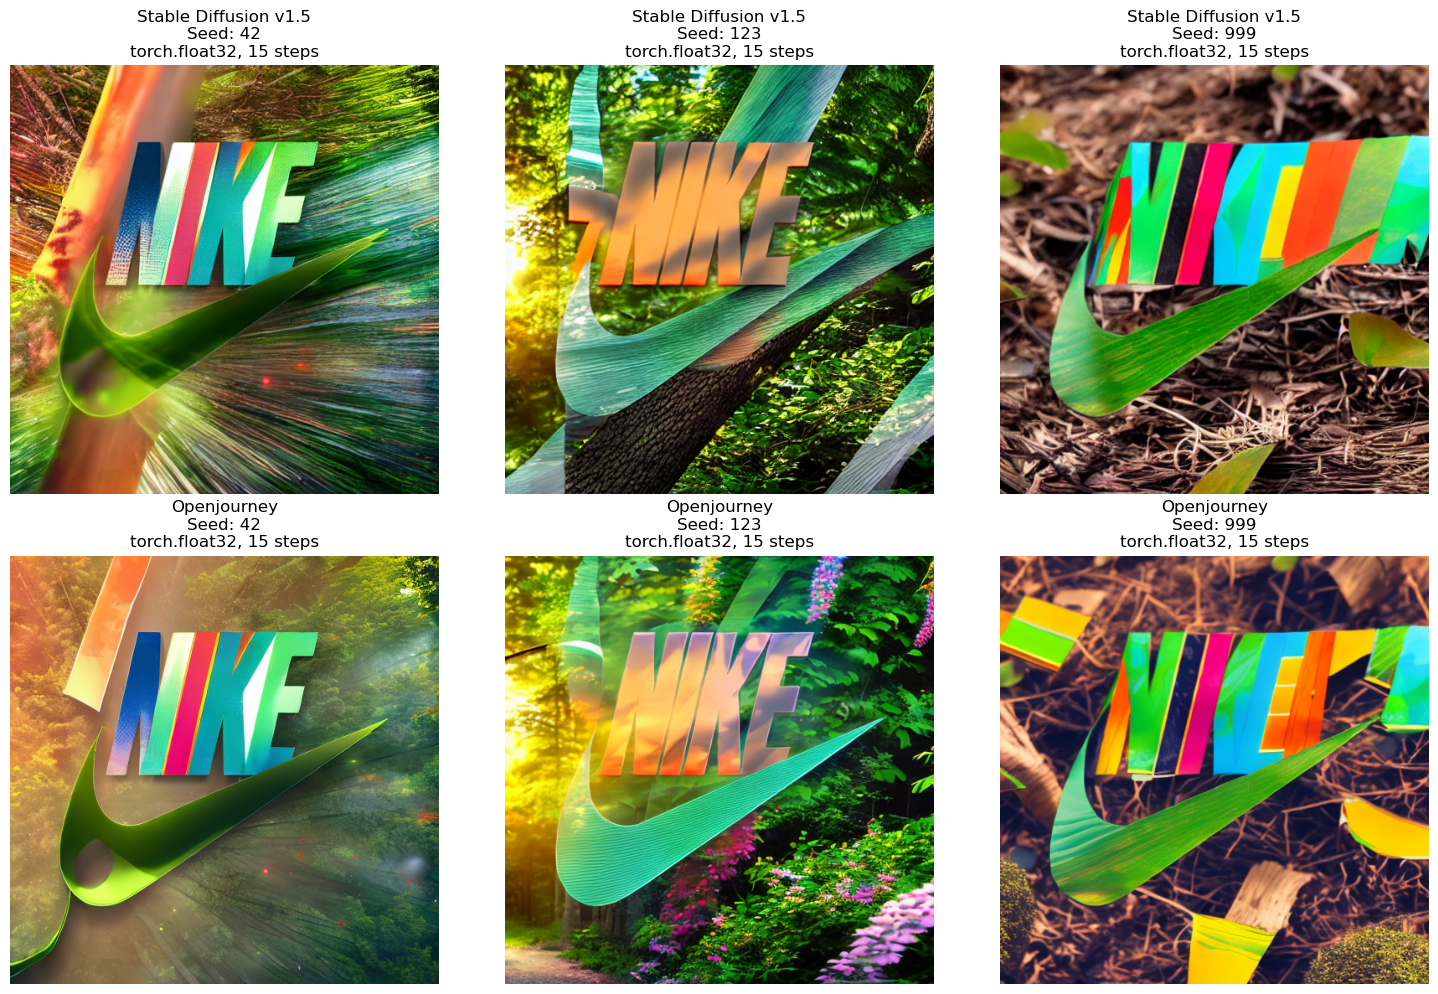

In [5]:
os.makedirs("results/model_comparisons", exist_ok=True)  # Ensure folder exist

# 🔍 Plot results with dtype and steps info
fig, axes = plt.subplots(len(models), len(seeds), figsize=(5 * len(seeds), 5 * len(models)))

for i, (model_name, images) in enumerate(results.items()):
    for j, img in enumerate(images):
        ax = axes[i, j] if len(models) > 1 else axes[j]
        ax.imshow(img)
        ax.axis('off')
        ax.set_title(f"{model_name}\nSeed: {seeds[j]}\n{dtype}, {steps} steps")

plt.tight_layout()
plt.savefig("results/model_comparisons/model_comparison_v3.png", dpi=300)
plt.show()

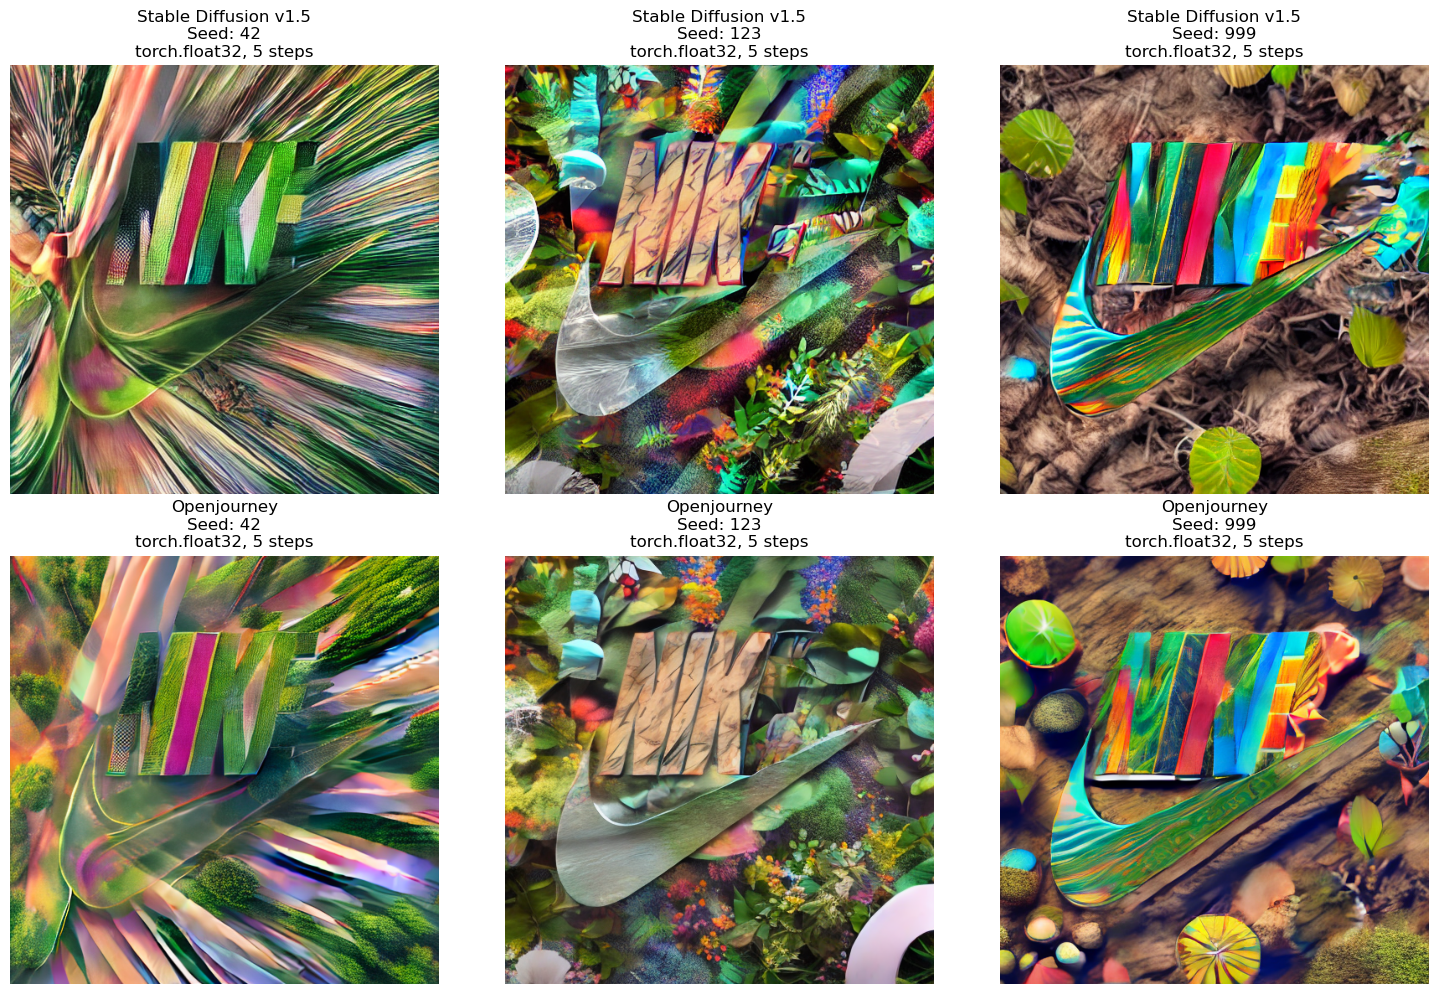

In [3]:
os.makedirs("results/model_comparisons", exist_ok=True)  # Ensure folder exist

# 🔍 Plot results with dtype and steps info
fig, axes = plt.subplots(len(models), len(seeds), figsize=(5 * len(seeds), 5 * len(models)))

for i, (model_name, images) in enumerate(results.items()):
    for j, img in enumerate(images):
        ax = axes[i, j] if len(models) > 1 else axes[j]
        ax.imshow(img)
        ax.axis('off')
        ax.set_title(f"{model_name}\nSeed: {seeds[j]}\n{dtype}, {steps} steps")

plt.tight_layout()
plt.savefig("results/model_comparisons/model_comparison_v3.png", dpi=300)
plt.show()